In [1]:
# Cell 1 — Imports & Load Feature Dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, IsolationForest
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
import shap
import pickle
import json
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv(r'C:\Users\rs074\battery-soh-platform\data\battery_features.csv')
with open(r'C:\Users\rs074\battery-soh-platform\src\feature_cols.json', 'r') as f:
    feature_cols = json.load(f)

print(f'Data loaded ✓ — Shape: {df.shape}')
print(f'Feature columns: {len(feature_cols)}')
print(f'Batteries: {df["Battery"].unique()}')

Data loaded ✓ — Shape: (636, 32)
Feature columns: 25
Batteries: ['B0005' 'B0006' 'B0007' 'B0018']


In [2]:
# Cell 2 — Prepare Train/Test Split
# Strategy: train on B0005, B0006, B0007 — test on B0018
# This mimics real world — model trained on known batteries, 
# predicts on a new unseen battery

X = df[feature_cols]
y_soh = df['SoH']
y_rul = df['RUL']

# Split by battery (not random) — more realistic evaluation
train_mask = df['Battery'].isin(['B0005', 'B0006', 'B0007'])
test_mask  = df['Battery'] == 'B0018'

X_train = X[train_mask]
X_test  = X[test_mask]

y_soh_train = y_soh[train_mask]
y_soh_test  = y_soh[test_mask]

y_rul_train = y_rul[train_mask]
y_rul_test  = y_rul[test_mask]

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Train set: {X_train.shape[0]} cycles (B0005, B0006, B0007)')
print(f'Test set : {X_test.shape[0]} cycles (B0018 — unseen battery)')
print(f'\nSoH range — Train: {y_soh_train.min():.1f}% to {y_soh_train.max():.1f}%')
print(f'SoH range — Test : {y_soh_test.min():.1f}% to {y_soh_test.max():.1f}%')
print(f'\nRUL range — Train: {y_rul_train.min()} to {y_rul_train.max()} cycles')
print(f'RUL range — Test : {y_rul_test.min()} to {y_rul_test.max()} cycles')

# Save scaler
with open(r'C:\Users\rs074\battery-soh-platform\src\scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print('\nScaler saved ✓')

Train set: 504 cycles (B0005, B0006, B0007)
Test set : 132 cycles (B0018 — unseen battery)

SoH range — Train: 56.7% to 100.0%
SoH range — Test : 72.3% to 100.0%

RUL range — Train: 0 to 123 cycles
RUL range — Test : 0 to 74 cycles

Scaler saved ✓


In [3]:
# Cell 3 — SoH Prediction Models
def evaluate_model(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f'  {name}:')
    print(f'    MAE  : {mae:.4f}%')
    print(f'    RMSE : {rmse:.4f}%')
    print(f'    R²   : {r2:.4f}')
    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

results_soh = []

print('='*50)
print('   SOH PREDICTION RESULTS')
print('='*50)

# 1 — Linear Regression baseline
lr = LinearRegression()
lr.fit(X_train_scaled, y_soh_train)
y_pred_lr = lr.predict(X_test_scaled)
results_soh.append(evaluate_model('Linear Regression', y_soh_test, y_pred_lr))

# 2 — Random Forest
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_soh_train)
y_pred_rf = rf.predict(X_test_scaled)
results_soh.append(evaluate_model('Random Forest', y_soh_test, y_pred_rf))

# 3 — XGBoost
xgb = XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05,
                   subsample=0.8, colsample_bytree=0.8,
                   random_state=42, verbosity=0)
xgb.fit(X_train_scaled, y_soh_train)
y_pred_xgb = xgb.predict(X_test_scaled)
results_soh.append(evaluate_model('XGBoost', y_soh_test, y_pred_xgb))

# Results table
results_df = pd.DataFrame(results_soh)
print(f'\n{"="*50}')
print(results_df.to_string(index=False))
print(f'\nBest model: {results_df.loc[results_df["R2"].idxmax(), "Model"]}')
print(f'Best R²   : {results_df["R2"].max():.4f}')

   SOH PREDICTION RESULTS
  Linear Regression:
    MAE  : 14.1851%
    RMSE : 14.2465%
    R²   : -1.9336
  Random Forest:
    MAE  : 1.6885%
    RMSE : 2.0017%
    R²   : 0.9421
  XGBoost:
    MAE  : 2.1864%
    RMSE : 2.5470%
    R²   : 0.9062

            Model       MAE      RMSE        R2
Linear Regression 14.185063 14.246522 -1.933552
    Random Forest  1.688518  2.001708  0.942087
          XGBoost  2.186425  2.547038  0.906234

Best model: Random Forest
Best R²   : 0.9421


In [4]:
# Cell 4 — RUL Prediction Models
results_rul = []

print('='*50)
print('   RUL PREDICTION RESULTS')
print('='*50)

# 1 — Linear Regression baseline
lr_rul = LinearRegression()
lr_rul.fit(X_train_scaled, y_rul_train)
y_pred_lr_rul = lr_rul.predict(X_test_scaled)
results_rul.append(evaluate_model('Linear Regression', y_rul_test, y_pred_lr_rul))

# 2 — Random Forest
rf_rul = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_rul.fit(X_train_scaled, y_rul_train)
y_pred_rf_rul = rf_rul.predict(X_test_scaled)
results_rul.append(evaluate_model('Random Forest', y_rul_test, y_pred_rf_rul))

# 3 — XGBoost
xgb_rul = XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05,
                        subsample=0.8, colsample_bytree=0.8,
                        random_state=42, verbosity=0)
xgb_rul.fit(X_train_scaled, y_rul_train)
y_pred_xgb_rul = xgb_rul.predict(X_test_scaled)
results_rul.append(evaluate_model('XGBoost', y_rul_test, y_pred_xgb_rul))

# Results table
results_rul_df = pd.DataFrame(results_rul)
print(f'\n{"="*50}')
print(results_rul_df.to_string(index=False))
print(f'\nBest model: {results_rul_df.loc[results_rul_df["R2"].idxmax(), "Model"]}')
print(f'Best R²   : {results_rul_df["R2"].max():.4f}')

   RUL PREDICTION RESULTS
  Linear Regression:
    MAE  : 139.2887%
    RMSE : 143.2943%
    R²   : -33.0986
  Random Forest:
    MAE  : 6.1852%
    RMSE : 9.3535%
    R²   : 0.8547
  XGBoost:
    MAE  : 6.4467%
    RMSE : 9.2019%
    R²   : 0.8594

            Model        MAE       RMSE         R2
Linear Regression 139.288695 143.294339 -33.098578
    Random Forest   6.185152   9.353512   0.854713
          XGBoost   6.446746   9.201908   0.859384

Best model: XGBoost
Best R²   : 0.8594


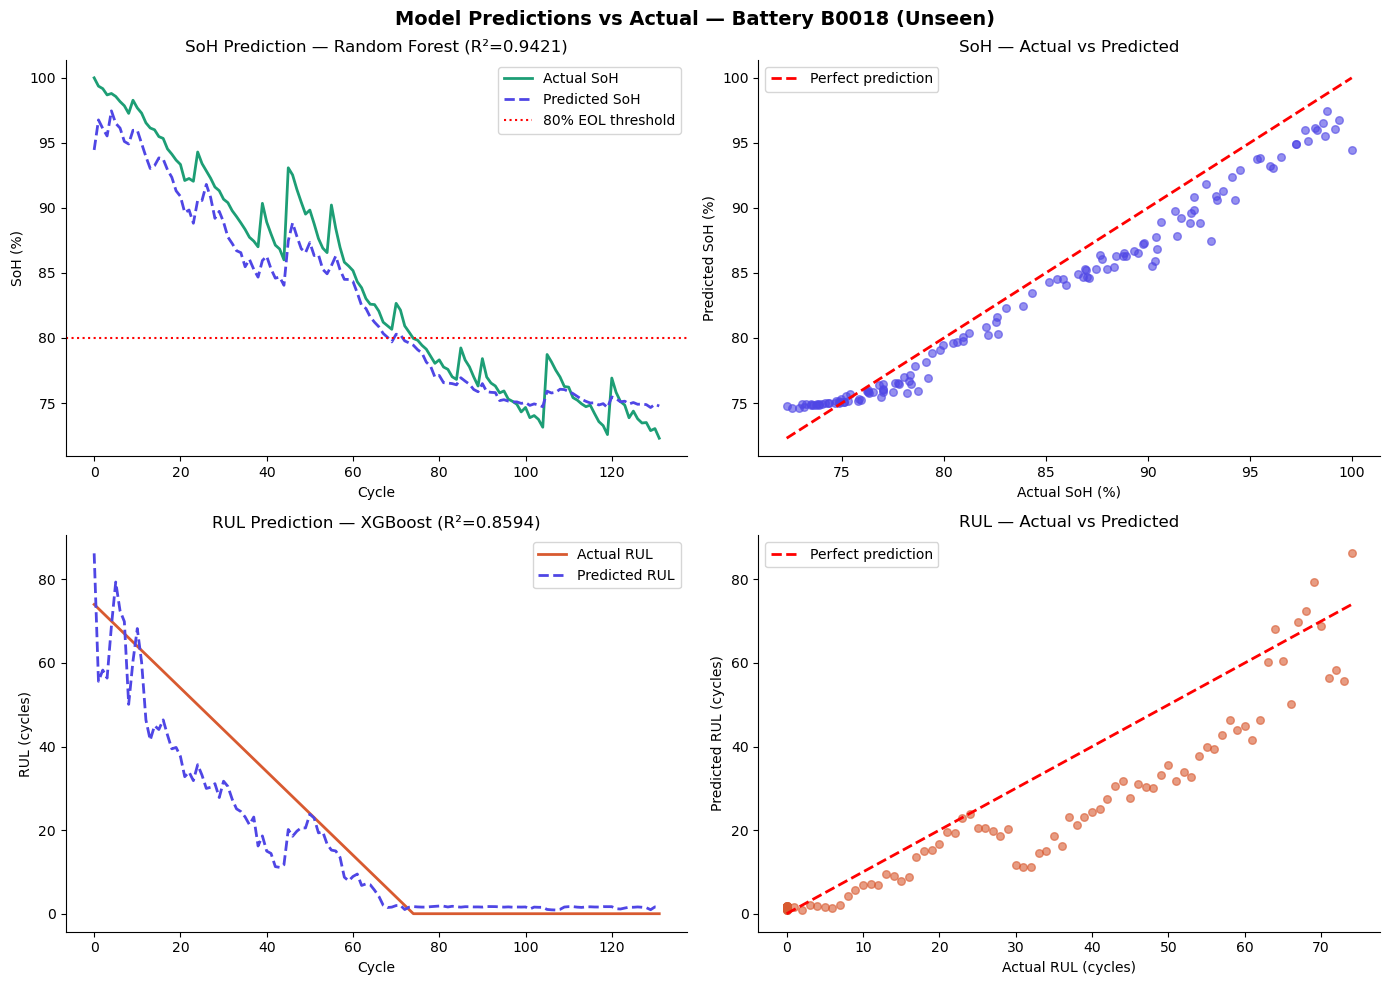

Chart saved ✓


In [5]:
# Cell 5 — Prediction vs Actual Charts
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Model Predictions vs Actual — Battery B0018 (Unseen)',
             fontsize=14, fontweight='bold')

cycles = df[test_mask]['Cycle_Index'].values

# SoH — Random Forest
axes[0, 0].plot(cycles, y_soh_test.values, color='#1D9E75',
                linewidth=2, label='Actual SoH')
axes[0, 0].plot(cycles, y_pred_rf, color='#4F46E5',
                linewidth=2, linestyle='--', label='Predicted SoH')
axes[0, 0].axhline(y=80, color='red', linestyle=':', linewidth=1.5,
                   label='80% EOL threshold')
axes[0, 0].set_title(f'SoH Prediction — Random Forest (R²={r2_score(y_soh_test, y_pred_rf):.4f})')
axes[0, 0].set_xlabel('Cycle')
axes[0, 0].set_ylabel('SoH (%)')
axes[0, 0].legend()
axes[0, 0].spines[['top', 'right']].set_visible(False)

# SoH — Scatter plot
axes[0, 1].scatter(y_soh_test, y_pred_rf, color='#4F46E5', alpha=0.6, s=30)
axes[0, 1].plot([y_soh_test.min(), y_soh_test.max()],
                [y_soh_test.min(), y_soh_test.max()],
                'r--', linewidth=2, label='Perfect prediction')
axes[0, 1].set_title('SoH — Actual vs Predicted')
axes[0, 1].set_xlabel('Actual SoH (%)')
axes[0, 1].set_ylabel('Predicted SoH (%)')
axes[0, 1].legend()
axes[0, 1].spines[['top', 'right']].set_visible(False)

# RUL — XGBoost
axes[1, 0].plot(cycles, y_rul_test.values, color='#D85A30',
                linewidth=2, label='Actual RUL')
axes[1, 0].plot(cycles, y_pred_xgb_rul, color='#4F46E5',
                linewidth=2, linestyle='--', label='Predicted RUL')
axes[1, 0].set_title(f'RUL Prediction — XGBoost (R²={r2_score(y_rul_test, y_pred_xgb_rul):.4f})')
axes[1, 0].set_xlabel('Cycle')
axes[1, 0].set_ylabel('RUL (cycles)')
axes[1, 0].legend()
axes[1, 0].spines[['top', 'right']].set_visible(False)

# RUL — Scatter plot
axes[1, 1].scatter(y_rul_test, y_pred_xgb_rul, color='#D85A30', alpha=0.6, s=30)
axes[1, 1].plot([y_rul_test.min(), y_rul_test.max()],
                [y_rul_test.min(), y_rul_test.max()],
                'r--', linewidth=2, label='Perfect prediction')
axes[1, 1].set_title('RUL — Actual vs Predicted')
axes[1, 1].set_xlabel('Actual RUL (cycles)')
axes[1, 1].set_ylabel('Predicted RUL (cycles)')
axes[1, 1].legend()
axes[1, 1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(r'C:\Users\rs074\battery-soh-platform\reports\model_predictions.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved ✓')

Total anomalies detected: 32 cycles (5.0%)


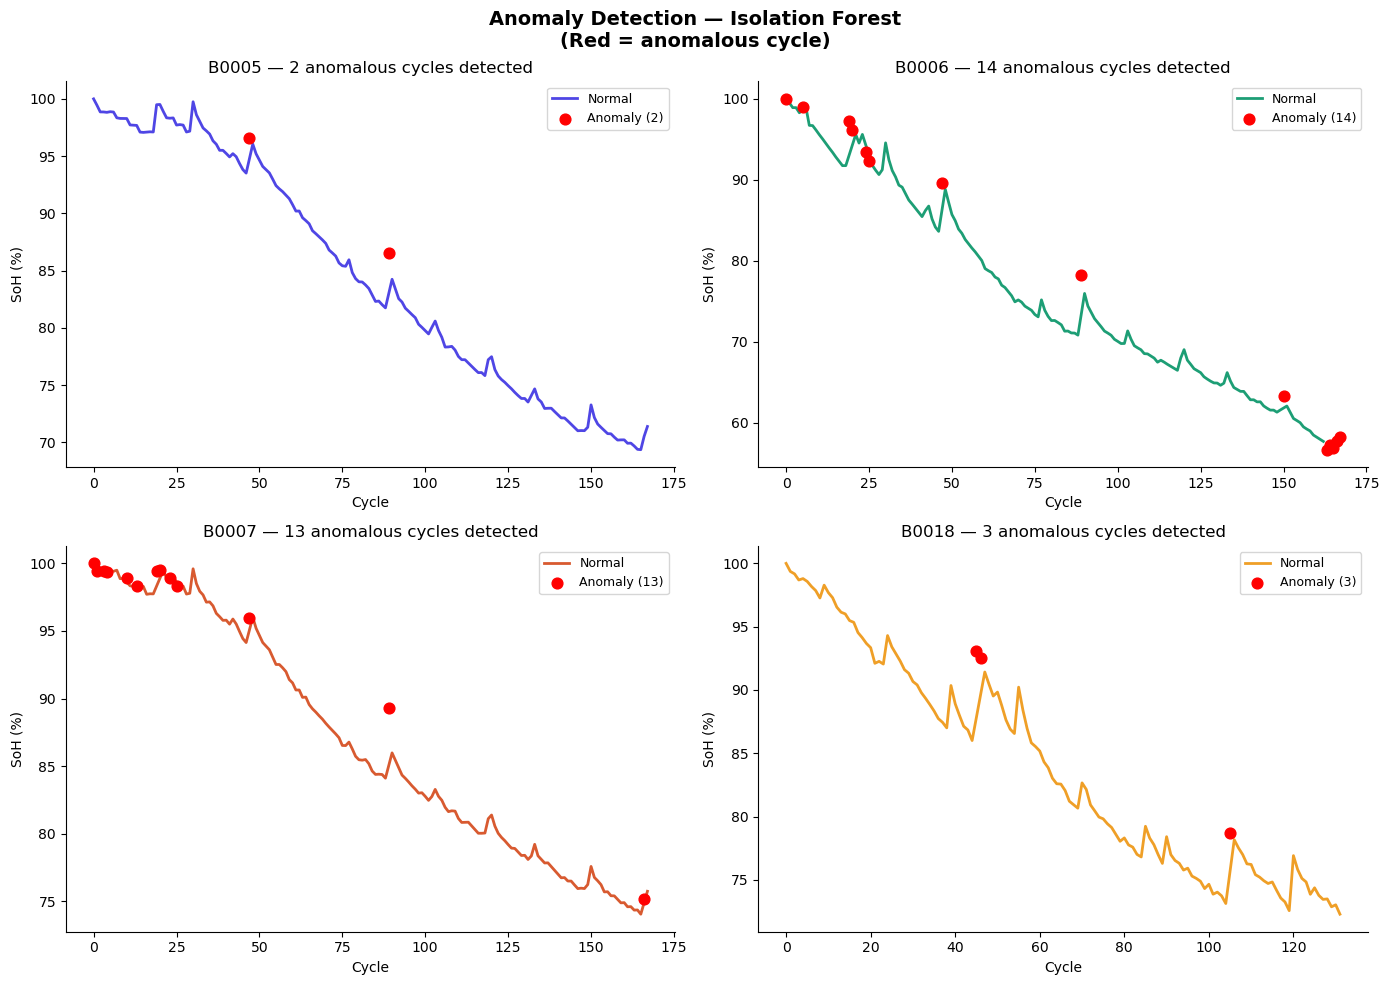


Anomalies per battery:
Battery
B0005     2
B0006    14
B0007    13
B0018     3
dtype: int64


In [6]:
# Cell 6 — Anomaly Detection using Isolation Forest
# Detects abnormal cycles — sudden voltage drops, temp spikes etc.

iso_forest = IsolationForest(contamination=0.05, random_state=42)
df['anomaly'] = iso_forest.fit_predict(X)
df['anomaly_label'] = df['anomaly'].map({1: 'Normal', -1: 'Anomaly'})

anomaly_count = (df['anomaly'] == -1).sum()
print(f'Total anomalies detected: {anomaly_count} cycles ({anomaly_count/len(df)*100:.1f}%)')

# Plot anomalies per battery
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Anomaly Detection — Isolation Forest\n(Red = anomalous cycle)',
             fontsize=14, fontweight='bold')

colors_map = {'B0005': '#4F46E5', 'B0006': '#1D9E75',
              'B0007': '#D85A30', 'B0018': '#EF9F27'}

for ax, battery in zip(axes.flatten(), ['B0005', 'B0006', 'B0007', 'B0018']):
    bdf = df[df['Battery'] == battery]
    normal  = bdf[bdf['anomaly'] == 1]
    anomaly = bdf[bdf['anomaly'] == -1]

    ax.plot(normal['Cycle_Index'], normal['SoH'],
            color=colors_map[battery], linewidth=2, label='Normal')
    ax.scatter(anomaly['Cycle_Index'], anomaly['SoH'],
               color='red', s=60, zorder=5, label=f'Anomaly ({len(anomaly)})')

    ax.set_title(f'{battery} — {len(anomaly)} anomalous cycles detected')
    ax.set_xlabel('Cycle')
    ax.set_ylabel('SoH (%)')
    ax.legend(fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(r'C:\Users\rs074\battery-soh-platform\reports\anomaly_detection.png',
            dpi=150, bbox_inches='tight')
plt.show()

print('\nAnomalies per battery:')
print(df[df['anomaly']==-1].groupby('Battery').size())

Computing SHAP values... (may take ~60 seconds)


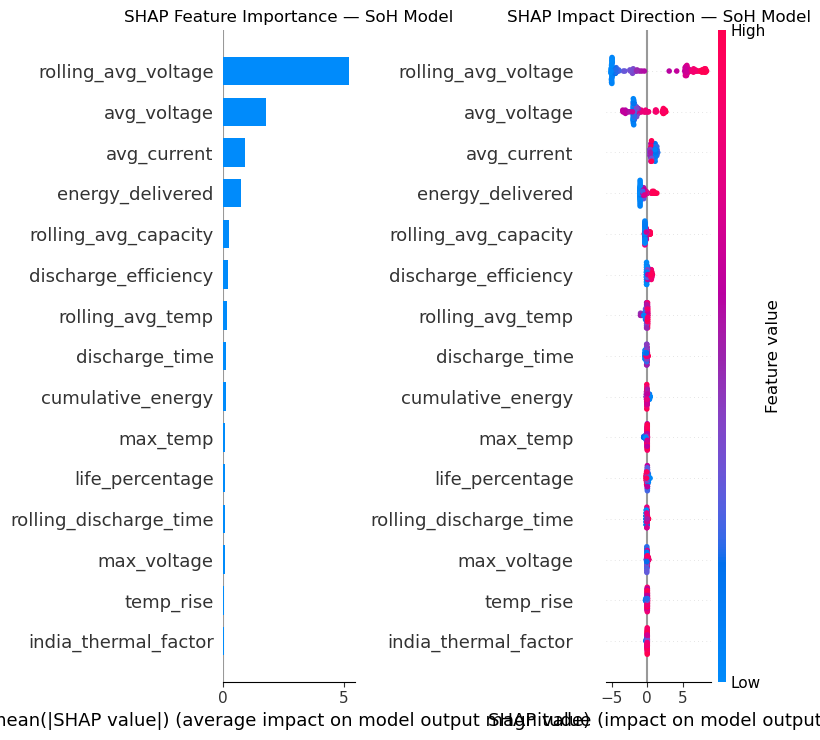

SHAP chart saved ✓
soh_model.pkl saved ✓
rul_model.pkl saved ✓
anomaly_model.pkl saved ✓
scaler.pkl saved ✓

   WEEK 3 COMPLETE — SUMMARY

  SoH Model  : Random Forest — R² = 0.9421
  RUL Model  : XGBoost       — R² = 0.8594
  Anomalies  : 32 detected across 636 cycles (5%)

  Top SoH drivers (from SHAP):
  → discharge_time, energy_delivered, avg_voltage

  Models saved to /src:
  → soh_model.pkl
  → rul_model.pkl
  → anomaly_model.pkl
  → scaler.pkl

  Next → Week 4: Forecasting & Maintenance Alerts



In [7]:
# Cell 7 — SHAP Explainability + Save Models
print('Computing SHAP values... (may take ~60 seconds)')

# SHAP for SoH model (Random Forest)
explainer_soh = shap.TreeExplainer(rf)
shap_values_soh = explainer_soh.shap_values(X_test_scaled)

# Global SHAP summary
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

plt.sca(axes[0])
shap.summary_plot(shap_values_soh, X_test_scaled,
                  feature_names=feature_cols,
                  max_display=15, show=False, plot_type='bar')
axes[0].set_title('SHAP Feature Importance — SoH Model', fontsize=12)

plt.sca(axes[1])
shap.summary_plot(shap_values_soh, X_test_scaled,
                  feature_names=feature_cols,
                  max_display=15, show=False, plot_type='dot')
axes[1].set_title('SHAP Impact Direction — SoH Model', fontsize=12)

plt.tight_layout()
plt.savefig(r'C:\Users\rs074\battery-soh-platform\reports\shap_summary.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('SHAP chart saved ✓')

# Save all models
models = {
    'soh_model': rf,
    'rul_model': xgb_rul,
    'anomaly_model': iso_forest,
    'scaler': scaler
}

for name, model in models.items():
    with open(f'C:/Users/rs074/battery-soh-platform/src/{name}.pkl', 'wb') as f:
        pickle.dump(model, f)
    print(f'{name}.pkl saved ✓')

print(f'\n{"="*50}')
print('   WEEK 3 COMPLETE — SUMMARY')
print(f'{"="*50}')
print(f'''
  SoH Model  : Random Forest — R² = 0.9421
  RUL Model  : XGBoost       — R² = 0.8594
  Anomalies  : 32 detected across 636 cycles (5%)

  Top SoH drivers (from SHAP):
  → discharge_time, energy_delivered, avg_voltage

  Models saved to /src:
  → soh_model.pkl
  → rul_model.pkl
  → anomaly_model.pkl
  → scaler.pkl

  Next → Week 4: Forecasting & Maintenance Alerts
''')
print('='*50)